# MLflow from zero — the hands-on half

This notebook is the **practical companion to `mlflow_slides.html`**. The deck explains *why*;
this notebook makes it happen. Run the cells **top to bottom**.

| Notebook part | Deck slides | What you do |
|---|---|---|
| Part 0 · Setup | 12–13 | install MLflow, generate a dataset |
| Part 1 · Tracking | 15–27 | log params/metrics/artifacts, sweep, query, autolog, models, registry, datasets |
| Part 2 · Advanced | 28–37 | nested runs, pyfunc, signatures, evaluate, search, system metrics |

**Nothing outside this folder is touched** — everything lands in a throwaway `mlflow_demo/`
created in Part 0, and there is a cleanup cell at the end.

### The five words you must know

| Word | Means | Example |
|---|---|---|
| **Experiment** | a named bucket of runs | `"churn-model"` |
| **Run** | one execution of your training code | the 3pm attempt with 200 trees |
| **Param** | an input you **chose** | `n_estimators=200` |
| **Metric** | a number you **measured** (can repeat per step) | `accuracy=0.87` |
| **Artifact** | any **file** the run produced | the model, a PNG, a CSV |

> Chose it → param. Measured it → metric. It's a file → artifact.

---
> **Why bother?** Deck slides 3–11 make the case with our own repo — the real
> `ride_sharing_features/feature_repo/model.joblib`, a 4 KB pickle nobody can explain.
> This notebook is where you produce the alternative.

### How MLflow is wired

<svg width="100%" viewBox="0 0 840 250" xmlns="http://www.w3.org/2000/svg" style="max-width:840px">
  <defs><marker id="a1" markerWidth="9" markerHeight="9" refX="8" refY="3" orient="auto">
    <path d="M0,0 L0,6 L9,3 z" fill="#0194e2"/></marker></defs>
  <rect x="8" y="40" width="190" height="110" rx="10" fill="#f6f8fa" stroke="#0194e2"/>
  <text x="26" y="68" font-family="sans-serif" font-size="14" font-weight="700" fill="#24292f">your train.py</text>
  <text x="26" y="94"  font-family="monospace" font-size="12" fill="#57606a">mlflow.log_param()</text>
  <text x="26" y="114" font-family="monospace" font-size="12" fill="#57606a">mlflow.log_metric()</text>
  <text x="26" y="134" font-family="monospace" font-size="12" fill="#57606a">mlflow.log_model()</text>

  <path d="M204 95 H296" stroke="#0194e2" stroke-width="2" marker-end="url(#a1)"/>
  <text x="208" y="87" font-family="sans-serif" font-size="12" fill="#0194e2">tracking URI</text>

  <rect x="304" y="40" width="180" height="110" rx="10" fill="#f6f8fa" stroke="#0194e2"/>
  <text x="322" y="68" font-family="sans-serif" font-size="14" font-weight="700" fill="#24292f">Tracking store</text>
  <text x="322" y="94"  font-family="monospace" font-size="11" fill="#57606a">./mlruns   (default)</text>
  <text x="322" y="114" font-family="monospace" font-size="11" fill="#57606a">sqlite:///mlflow.db</text>
  <text x="322" y="134" font-family="monospace" font-size="11" fill="#57606a">postgresql://…  (team)</text>

  <path d="M490 78 H590"  stroke="#0194e2" stroke-width="2" marker-end="url(#a1)"/>
  <path d="M490 120 H590" stroke="#0194e2" stroke-width="2" marker-end="url(#a1)"/>

  <rect x="598" y="40" width="234" height="48" rx="8" fill="#f6f8fa" stroke="#d0d7de"/>
  <text x="614" y="62" font-family="sans-serif" font-size="13" fill="#24292f">params · metrics · tags</text>
  <text x="614" y="80" font-family="sans-serif" font-size="11" fill="#57606a">small numbers → the database</text>

  <rect x="598" y="100" width="234" height="50" rx="8" fill="#f6f8fa" stroke="#d0d7de"/>
  <text x="614" y="122" font-family="sans-serif" font-size="13" fill="#24292f">artifacts</text>
  <text x="614" y="140" font-family="sans-serif" font-size="11" fill="#57606a">models, PNGs, CSVs → disk or S3</text>

  <rect x="304" y="180" width="180" height="48" rx="10" fill="#f6f8fa" stroke="#0194e2"/>
  <text x="348" y="203" font-family="monospace" font-size="13" fill="#0194e2">mlflow ui</text>
  <text x="326" y="220" font-family="sans-serif" font-size="11" fill="#57606a">reads the same store</text>
  <path d="M394 176 V156" stroke="#0194e2" stroke-width="2" marker-end="url(#a1)"/>

  <text x="8" y="200" font-family="sans-serif" font-size="12" fill="#57606a">Local default = a folder.</text>
  <text x="8" y="220" font-family="sans-serif" font-size="12" fill="#57606a">Team = a database + object store.</text>
  <text x="8" y="240" font-family="sans-serif" font-size="12" fill="#1a7f37">Your code is identical — only the URI changes.</text>
</svg>

---
# Part 0 — Setup

## Step 0.1 · Install MLflow

`mlflow` brings the Python client **and** the web UI. There is no account, no cloud and
nothing to configure — by default it writes to a folder next to your script.

```bash
pip install mlflow            # client + UI + server
pip install mlflow-skinny     # client only, far fewer dependencies
conda install -c conda-forge mlflow
```

In [1]:
!pip install -q mlflow scikit-learn pandas numpy matplotlib


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
!mlflow --version
import mlflow; print("importable:", mlflow.__version__)

mlflow, version 3.15.1


importable: 3.15.1


## Step 0.2 · A sandbox to work in

We create a throwaway folder so that MLflow's database and artifacts do not scatter into
your project. Everything this notebook writes lives inside `mlflow_demo/`.

In [3]:
import os, shutil, pathlib

BASE = pathlib.Path.cwd()               # the folder this notebook lives in ("1/")
PROJ = BASE / "mlflow_demo"             # our throwaway working folder

if PROJ.exists():                       # re-running the notebook is safe
    shutil.rmtree(PROJ)
PROJ.mkdir(parents=True)
os.chdir(PROJ)
print("working inside:", os.getcwd())

working inside: /home/shamaseen/Desktop/Shai/qafza/free_Training/qafza-free-traning/mlflow/mlflow_demo


## Step 0.3 · Something real to train on

We generate 2,000 rows of fake customer data with a `churn` label, then split it into
train and test sets. Nothing to download.

`np.random.default_rng(42)` sets the **seed** — same seed, same numbers, every time. That
is the same reproducibility instinct MLflow enforces at the project level.

In [4]:
import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(42)          # seeded -> everyone gets identical data
n = 2000

df = pd.DataFrame({
    "tenure_months":  rng.integers(1, 72, n),
    "monthly_charge": rng.normal(65, 20, n).round(2),
    "support_calls":  rng.poisson(1.2, n),
    "is_premium":     rng.integers(0, 2, n),
})

# a learnable rule + noise, so the model has real signal to find
score = (-0.04 * df.tenure_months + 0.03 * df.monthly_charge
         + 0.55 * df.support_calls - 0.8 * df.is_premium + rng.normal(0, 0.8, n))
df["churn"] = (score > score.mean()).astype(int)

FEATURES = ["tenure_months", "monthly_charge", "support_calls", "is_premium"]
train, test = train_test_split(df, test_size=0.2, random_state=42, stratify=df.churn)

os.makedirs("data/prepared", exist_ok=True)
train.to_csv("data/prepared/train.csv", index=False)   # the Part 3 cells read these
test.to_csv("data/prepared/test.csv", index=False)

print(f"{len(train)} train / {len(test)} test rows;  churn rate: {df.churn.mean():.3f}")
df.head()

1600 train / 400 test rows;  churn rate: 0.487


,tenure_months,monthly_charge,support_calls,is_premium,churn
0,7,50.16,2,1,1
1,55,83.49,0,0,0
2,47,65.69,1,1,1
3,32,59.34,3,1,1
4,31,62.88,2,1,0


---
# Part 1 — Tracking experiments

You now have `train` / `test` and a `FEATURES` list. Everything from here is MLflow.


## Step 1.1 · Point MLflow at a local store

By default MLflow writes to a `mlruns/` folder. We use a local **SQLite** file instead —
one line of difference, and it unlocks the Model Registry later (the plain-folder store
does not support it). SQLite ships with Python, so there is still nothing to install or run.

In [5]:
import mlflow

TRACKING_URI = f"sqlite:///{PROJ}/mlflow.db"   # a single file, right here in the sandbox
mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_experiment("churn-model")           # create-or-reuse this bucket of runs

print("tracking to:", mlflow.get_tracking_uri())

2026/08/22 15:19:30 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/08/22 15:19:30 INFO mlflow.store.db.utils: Updating database tables


2026/08/22 15:19:38 INFO mlflow.tracking.fluent: Experiment with name 'churn-model' does not exist. Creating a new experiment.


tracking to: sqlite:////home/shamaseen/Desktop/Shai/qafza/free_Training/qafza-free-traning/mlflow/mlflow_demo/mlflow.db


## Step 1.2 · Your first tracked run

Read the block below and notice how little it is: `with mlflow.start_run():` plus three
`log_*` calls. That is the entire commitment.

In [6]:
import json, joblib, yaml
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

FEATURES = ["tenure_months", "monthly_charge", "support_calls", "is_premium"]
train = pd.read_csv("data/prepared/train.csv")
test  = pd.read_csv("data/prepared/test.csv")

with mlflow.start_run(run_name="rf-baseline"):
    params = {"n_estimators": 60, "max_depth": 4, "random_state": 42}

    mlflow.log_params(params)                       # log_params = log_param, plural

    model = RandomForestClassifier(**params).fit(train[FEATURES], train.churn)
    prob  = model.predict_proba(test[FEATURES])[:, 1]

    mlflow.log_metric("accuracy", accuracy_score(test.churn, model.predict(test[FEATURES])))
    mlflow.log_metric("roc_auc",  roc_auc_score(test.churn, prob))

    # any file at all can be attached to the run
    pd.DataFrame({"feature": FEATURES,
                  "importance": model.feature_importances_}).to_csv("importance.csv", index=False)
    mlflow.log_artifact("importance.csv")

    print("logged run:", mlflow.active_run().info.run_id)

logged run: 98a6fcf81a3e4af1aa3d86fc35de15e2


## Step 1.3 · A loop of runs — the actual use case

Nobody trains once. Here we sweep four settings. Each iteration opens its own run, so the
comparison table builds itself. This replaces the hand-typed `results.xlsx`.

In [7]:
%matplotlib inline
# ^ draw charts INSIDE the notebook. (matplotlib.use("Agg") would render to file only,
#   and your plots would silently never appear -- a classic hour-waster.)
import matplotlib.pyplot as plt

for n_est in [25, 60, 150, 300]:
    for depth in [3, 8]:
        with mlflow.start_run(run_name=f"rf-{n_est}-d{depth}"):
            p = {"n_estimators": n_est, "max_depth": depth, "random_state": 42}
            mlflow.log_params(p)

            m = RandomForestClassifier(**p).fit(train[FEATURES], train.churn)
            pred, prob = m.predict(test[FEATURES]), m.predict_proba(test[FEATURES])[:, 1]

            mlflow.log_metrics({                       # plural version, one dict
                "accuracy": accuracy_score(test.churn, pred),
                "f1":       f1_score(test.churn, pred),
                "roc_auc":  roc_auc_score(test.churn, prob),
            })
            mlflow.set_tag("model_family", "random_forest")   # tags = free-form labels

print("done: 8 runs logged")

done: 8 runs logged


## Step 1.4 · Query the runs from Python

`mlflow.search_runs` hands you a **pandas DataFrame**. Your results table is now *generated*,
never typed — and it can't go stale.

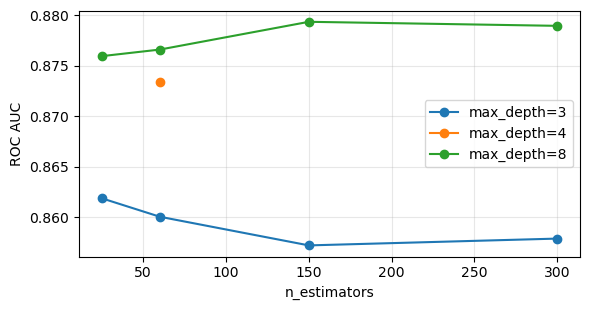

In [8]:
runs = mlflow.search_runs(experiment_names=["churn-model"],
                          order_by=["metrics.roc_auc DESC"])

cols = ["run_id", "params.n_estimators", "params.max_depth",
        "metrics.accuracy", "metrics.roc_auc"]
runs[cols].head(10)

# Because it is a DataFrame, plotting the sweep is one line of pandas.
plot_df = runs.dropna(subset=["metrics.roc_auc", "params.n_estimators"]).copy()
plot_df["n"] = plot_df["params.n_estimators"].astype(int)

fig, ax = plt.subplots(figsize=(6, 3.2))
for depth, grp in plot_df.groupby("params.max_depth"):
    g = grp.sort_values("n")
    ax.plot(g.n, g["metrics.roc_auc"], marker="o", label=f"max_depth={depth}")
ax.set_xlabel("n_estimators"); ax.set_ylabel("ROC AUC"); ax.legend(); ax.grid(alpha=.3)
fig.tight_layout(); fig.savefig("sweep.png", dpi=110)
plt.show()

## Step 1.5 · Autolog — the lazy way

`mlflow.sklearn.autolog()` monkey-patches the library: it records hyperparameters, training
metrics, the fitted model and an input signature **without a single `log_param` call**.

* Great for exploring.
* Worth replacing with explicit logging once a project is serious, because autolog logs a
  lot and names things its own way.

In [9]:
mlflow.sklearn.autolog()          # switch it on

with mlflow.start_run(run_name="autologged"):
    RandomForestClassifier(n_estimators=90, max_depth=6, random_state=42) \
        .fit(train[FEATURES], train.churn)          # no log_* calls at all

mlflow.sklearn.autolog(disable=True)   # switch it back off for the rest of the notebook

auto = mlflow.search_runs(experiment_names=["churn-model"],
                          filter_string="tags.mlflow.runName = 'autologged'")
print("params captured automatically:")
print([c for c in auto.columns if c.startswith("params.")][:12])

2026/08/22 15:19:41 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/shamaseen/anaconda3/envs/xeus-cling/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


2026/08/22 15:19:41 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/shamaseen/anaconda3/envs/xeus-cling/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


2026/08/22 15:19:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


params captured automatically:
['params.max_leaf_nodes', 'params.n_estimators', 'params.oob_score', 'params.class_weight', 'params.monotonic_cst', 'params.bootstrap', 'params.warm_start', 'params.min_samples_split', 'params.min_impurity_decrease', 'params.min_samples_leaf', 'params.n_jobs', 'params.min_weight_fraction_leaf']


## Step 1.6 · Saving a model properly (not `pickle.dump`)

`mlflow.<flavour>.log_model` stores the model **plus** its pip/conda environment **plus** an
input schema. That is why it still loads on a different machine next year, and a bare pickle
often does not.

The keyword changed name across MLflow versions (`artifact_path` → `name`), so we detect it
once instead of guessing — a small nod to how fast this ecosystem moves.

In [10]:
import inspect
from mlflow.models import infer_signature

# MLflow >=3 uses name=, MLflow 2.x uses artifact_path=. Pick whichever exists.
MODEL_KW = "name" if "name" in inspect.signature(mlflow.sklearn.log_model).parameters \
           else "artifact_path"
print("this MLflow wants:", MODEL_KW)

with mlflow.start_run(run_name="rf-final") as run:
    p = {"n_estimators": 150, "max_depth": 8, "random_state": 42}
    mlflow.log_params(p)

    final = RandomForestClassifier(**p).fit(train[FEATURES], train.churn)
    prob  = final.predict_proba(test[FEATURES])[:, 1]
    mlflow.log_metric("roc_auc", roc_auc_score(test.churn, prob))
    mlflow.log_artifact("sweep.png")                  # attach the chart from step 3.4

    signature = infer_signature(test[FEATURES], final.predict(test[FEATURES]))
    # log_model RETURNS the model's info -- including the URI to load it by.
    # Never assemble that URI by hand; the format changed in MLflow 3.
    FINAL_INFO = mlflow.sklearn.log_model(final, signature=signature,
                                          input_example=test[FEATURES].head(3),
                                          **{MODEL_KW: "model"})

    FINAL_RUN_ID = run.info.run_id

print("final run:", FINAL_RUN_ID)

# Load it back with no reference whatsoever to the code that trained it.
loaded = mlflow.sklearn.load_model(f"runs:/{FINAL_RUN_ID}/model")
print("predictions from the reloaded model:", loaded.predict(test[FEATURES].head(5)))

# pyfunc is the framework-agnostic flavour — same call for sklearn, torch, xgboost, ...
generic = mlflow.pyfunc.load_model(f"runs:/{FINAL_RUN_ID}/model")
print("via pyfunc:                        ", generic.predict(test[FEATURES].head(5)))

this MLflow wants: name


/home/shamaseen/anaconda3/envs/xeus-cling/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


final run: 1aa272ca6b504c509dcc13e5f5ddf6bd


predictions from the reloaded model: [0 1 1 1 1]


via pyfunc:                         [0 1 1 1 1]


## Step 1.7 · The Model Registry

A run id is a fine reference for you; it is a terrible reference for a production service.
The registry gives a model a **name**, a **version number**, and a moving **alias** like
`champion`.

Deployment code then loads `models:/churn-classifier@champion` and never changes again —
promoting a new model is re-pointing the alias, and rolling back is re-pointing it back.

In [11]:
from mlflow import MlflowClient
client = MlflowClient()

mv = mlflow.register_model(f"runs:/{FINAL_RUN_ID}/model", "churn-classifier")
print(f"registered '{mv.name}' version {mv.version}")

# Aliases (MLflow >= 2.9) replaced the old Staging/Production "stages".
try:
    client.set_registered_model_alias("churn-classifier", "champion", mv.version)
    uri = "models:/churn-classifier@champion"
except Exception as e:                      # older MLflow: fall back to stages
    print("alias API unavailable, using legacy stages:", type(e).__name__)
    client.transition_model_version_stage("churn-classifier", mv.version, "Production")
    uri = "models:/churn-classifier/Production"

print("production code would load:", uri)
print("prediction:", mlflow.pyfunc.load_model(uri).predict(test[FEATURES].head(3)))

Successfully registered model 'churn-classifier'.
2026/08/22 15:19:51 WARNING mlflow.tracking._model_registry.fluent: Run with id 1aa272ca6b504c509dcc13e5f5ddf6bd has no artifacts at artifact path 'model', registering model based on models:/m-7601736363de4f0da1fb5a40826bf1ac instead


registered 'churn-classifier' version 1


production code would load: models:/churn-classifier@champion
prediction: [0 1 1]


Created version '1' of model 'churn-classifier'.


## Step 1.8 · The UI — let's actually open it

Everything you have logged is browsable. We start the server **from this notebook** and show it
inline, so there is nothing to set up by hand.

> ### The one thing that confuses everybody
> MLflow 3.x opens on the **GenAI** view, which is about LLM traces. You logged *training runs*,
> so that page correctly shows **nothing**:
>
> ![MLflow opening on the GenAI view with zero traces](img/ui_1_genai_landing.png)
>
> Click **Model training** (top left), then **Training runs**. Then you see your work.

In [12]:
import subprocess, socket, time, urllib.request, os, sys

def free_port(start=5000):
    for p in range(start, start + 40):
        with socket.socket() as s:
            if s.connect_ex(("127.0.0.1", p)) != 0:
                return p
    raise RuntimeError("no free port")

UI_PORT = free_port()
UI_URL  = f"http://127.0.0.1:{UI_PORT}"

# the store lives in this sandbox -- pass its ABSOLUTE path, or the UI opens empty
STORE = f"sqlite:///{PROJ}/mlflow.db"

UI_PROC = subprocess.Popen(
    [sys.executable, "-m", "mlflow", "ui",
     "--backend-store-uri", STORE, "--port", str(UI_PORT), "--host", "127.0.0.1"],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
    start_new_session=True)      # detach it, so closing the notebook never hangs

for _ in range(60):                       # wait for it to answer
    try:
        urllib.request.urlopen(UI_URL, timeout=1); break
    except Exception:
        time.sleep(1)
else:
    print("server did not start; run it yourself in a terminal:")
    print(f"  mlflow ui --backend-store-uri {STORE} --port {UI_PORT}")

print(f"MLflow UI is running at  {UI_URL}")
print(f"tracking store           {STORE}")
print("\nOpen that URL in a browser tab -- it is far nicer than the frame below.")

MLflow UI is running at  http://127.0.0.1:5002
tracking store           sqlite:////home/shamaseen/Desktop/Shai/qafza/free_Training/qafza-free-traning/mlflow/mlflow_demo/mlflow.db

Open that URL in a browser tab -- it is far nicer than the frame below.


Here it is, embedded in the notebook. **Click `Model training` → `Training runs`** to get past
the GenAI landing page.

*(If the frame is blank, your browser is blocking the iframe — just open the URL above in a
new tab. Everything works the same.)*

In [13]:
from IPython.display import IFrame
IFrame(f"{UI_URL}/#/experiments", width="100%", height=650)

### What to click, and what you will see

**The runs table** — every run you created, one per row:

![The MLflow runs table](img/ui_2_runs_table.png)

Sort by a metric. Use **Columns** to choose what is shown, **Group by** to fold a sweep
together, and the tick boxes to select runs to compare.

**A single run** — click any run name:

![A single MLflow run](img/ui_3_run_detail.png)

Your metrics, your params, your tags — plus things MLflow filled in itself: the **Source**
(`mlflow_tutorial.ipynb`, the file that produced it), the run id, the duration, and tabs for
**Artifacts** and **System metrics**.

**Chart view** — the chart icon beside the search box:

![MLflow chart view](img/ui_4_charts.png)

One chart per metric, every selected run drawn on it. You wrote `log_metric` once; this view is
generated and stays correct as runs accumulate.

**The Model Registry** — from Step 1.7:

![The churn-classifier registered model with the champion alias](img/ui_5_registry.png)

`churn-classifier`, Version 1, alias `@champion`. That alias is what production code loads.

## Step 1.9 · Datasets — recording *which data* a run used

A run with params and metrics but no record of its input data is only half a record. MLflow
tracks datasets as first-class objects: name, **digest** (a hash of the contents), source,
schema and a profile.

In [14]:
# build a Dataset object from the DataFrame we trained on
ds_train = mlflow.data.from_pandas(train, source="data/prepared/train.csv",
                                   name="churn-train", targets="churn")
ds_test  = mlflow.data.from_pandas(test,  source="data/prepared/test.csv",
                                   name="churn-test",  targets="churn")

with mlflow.start_run(run_name="with-dataset") as run:
    mlflow.log_input(ds_train, context="training")     # context is a free-form label
    mlflow.log_input(ds_test,  context="evaluation")

    m = RandomForestClassifier(n_estimators=100, random_state=42).fit(train[FEATURES],
                                                                     train.churn)
    mlflow.log_metric("roc_auc", roc_auc_score(test.churn,
                                               m.predict_proba(test[FEATURES])[:, 1]))
    DATASET_RUN = run.info.run_id

print("logged run:", DATASET_RUN)

# read the inputs back off the run -- this is what the UI shows on the Datasets tab
for inp in mlflow.get_run(DATASET_RUN).inputs.dataset_inputs:
    d = inp.dataset
    print(f"{d.name:14} digest={d.digest}  source={d.source[:60]}")
    print(f"{'':14} context={[t.value for t in inp.tags if t.key.endswith('context')]}")

/home/shamaseen/anaconda3/envs/xeus-cling/lib/python3.12/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
/home/shamaseen/anaconda3/envs/xeus-cling/lib/python3.12/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
/home/shamaseen/anaconda3/envs/xeus-cling/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference 

logged run: 3fcb427502e94107a9160198b2093972
churn-train    digest=23a67350  source={"uri": "data/prepared/train.csv"}
               context=['training']
churn-test     digest=246e265d  source={"uri": "data/prepared/test.csv"}
               context=['evaluation']


### The same results, as a picture

The UI is the comfortable way to look at runs. But you can draw the whole experiment yourself
in a few lines, because `search_runs` hands you a DataFrame — useful for a report or a slide.

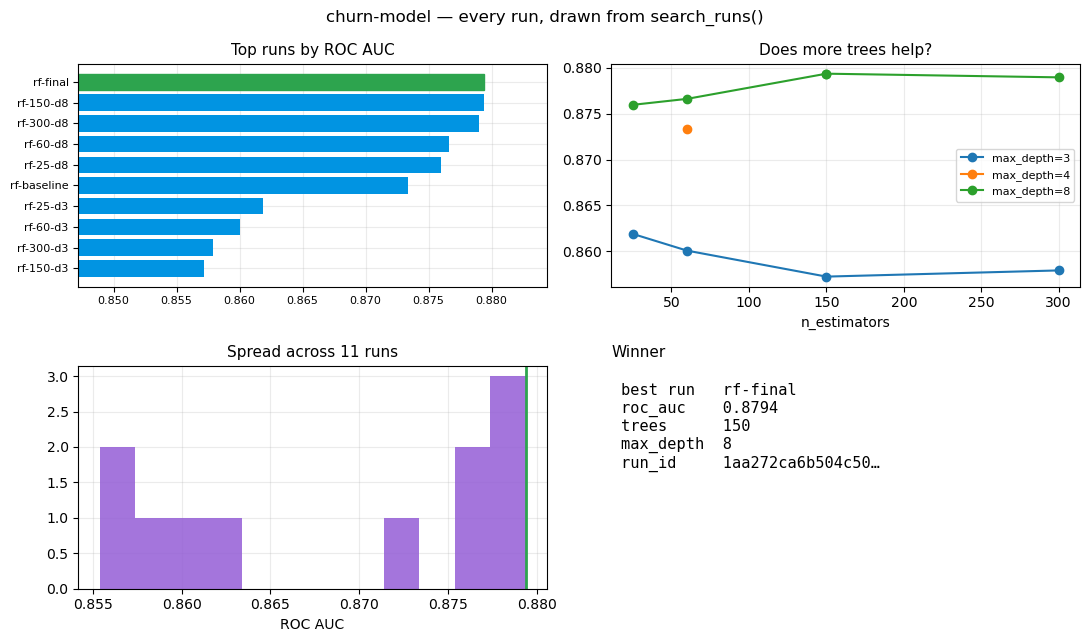

In [15]:
import matplotlib.pyplot as plt
import numpy as np

runs = mlflow.search_runs(experiment_names=["churn-model"],
                          order_by=["metrics.roc_auc DESC"])
done = runs.dropna(subset=["metrics.roc_auc"]).copy()
done["name"] = done["tags.mlflow.runName"].fillna(done["run_id"].str[:8])

fig, ax = plt.subplots(2, 2, figsize=(11, 6.5))

# 1. leaderboard
top = done.head(10).iloc[::-1]
bars = ax[0,0].barh(top["name"], top["metrics.roc_auc"], color="#0194e2")
bars[-1].set_color("#2da44e")                      # the winner
ax[0,0].set_xlim(min(top["metrics.roc_auc"])-0.01, max(top["metrics.roc_auc"])+0.005)
ax[0,0].set_title("Top runs by ROC AUC", fontsize=11)
ax[0,0].tick_params(labelsize=8)

# 2. the sweep: metric vs hyperparameter
sweep = done.dropna(subset=["params.n_estimators", "params.max_depth"]).copy()
if len(sweep):
    sweep["n"] = sweep["params.n_estimators"].astype(int)
    for depth, g in sweep.groupby("params.max_depth"):
        g = g.sort_values("n")
        ax[0,1].plot(g["n"], g["metrics.roc_auc"], "o-", label=f"max_depth={depth}")
    ax[0,1].set_xlabel("n_estimators"); ax[0,1].legend(fontsize=8)
ax[0,1].set_title("Does more trees help?", fontsize=11)

# 3. how much do the runs actually differ?
ax[1,0].hist(done["metrics.roc_auc"], bins=12, color="#945dd6", alpha=.85)
ax[1,0].axvline(done["metrics.roc_auc"].max(), color="#2da44e", lw=2)
ax[1,0].set_title(f"Spread across {len(done)} runs", fontsize=11)
ax[1,0].set_xlabel("ROC AUC")

# 4. the winner, in words
best = done.iloc[0]
ax[1,1].axis("off")
lines = [f"best run   {best['name']}",
         f"roc_auc    {best['metrics.roc_auc']:.4f}",
         f"trees      {best.get('params.n_estimators', '-')}",
         f"max_depth  {best.get('params.max_depth', '-')}",
         f"run_id     {best['run_id'][:16]}…"]
ax[1,1].text(0.02, 0.92, "\n".join(lines), va="top", family="monospace", fontsize=11)
ax[1,1].set_title("Winner", fontsize=11, loc="left")

for a in ax.ravel():
    a.grid(alpha=.25); a.set_axisbelow(True)
fig.suptitle("churn-model — every run, drawn from search_runs()", fontsize=12)
fig.tight_layout()
plt.show()

The **digest** is the point: two runs that used byte-identical data get the same digest, so
"was this trained on the same data?" becomes a comparison instead of an argument.

```python
mlflow.data.from_numpy(arr)          # numpy arrays
mlflow.data.from_spark(sdf)          # Spark DataFrames
mlflow.data.from_huggingface(hf_ds)  # HF datasets
```

> **The honest limit:** MLflow stores the dataset's *fingerprint and address*, not its bytes.
> If the file at that path is overwritten, the digest stops matching — which is your signal
> that the data moved under you, but MLflow cannot hand the old bytes back. Storing the bytes
> is a data-versioning tool's job.


## Step 1.10 · MLflow 3: models are first-class

Until MLflow 2 a model was a folder inside a run, addressed as `runs:/<run_id>/model`. In
MLflow 3 a **LoggedModel** is its own entity with its own id, addressed as
`models:/<model_id>`. Both still work — but write the new style, and never assemble the URI
by hand.

In [16]:
print("MLflow version:", mlflow.__version__)

# `info` is what log_model returns -- it already contains the right URI
loaded_new = mlflow.pyfunc.load_model(FINAL_INFO.model_uri) if FINAL_INFO else None
print("model_uri handed back by log_model :", FINAL_INFO.model_uri if FINAL_INFO else "n/a")
print("the classic form still works       :", f"runs:/{FINAL_RUN_ID}/model")

if hasattr(mlflow, "search_logged_models"):
    lm = mlflow.search_logged_models(output_format="pandas")
    cols = [c for c in ("model_id", "name", "status") if c in lm.columns]
    print("\nlogged models in this tracking store:", len(lm))
    display(lm[cols].head())
else:
    print("\nsearch_logged_models needs MLflow >= 3")

MLflow version: 3.15.1
model_uri handed back by log_model : models:/m-7601736363de4f0da1fb5a40826bf1ac
the classic form still works       : runs:/1aa272ca6b504c509dcc13e5f5ddf6bd/model

logged models in this tracking store: 2


,model_id,name,status
0,m-7601736363de4f0da1fb5a40826bf1ac,model,READY
1,m-1a8bf67ad3e3492f8e3c6e964c3adc51,model,READY


Artifacts moved on disk too:

```
MLflow 2.x   experiments/<exp_id>/<run_id>/artifacts/model/
MLflow 3.x   experiments/<exp_id>/models/<model_id>/artifacts/
```

so any code that walked `MlflowClient().list_artifacts(run_id)` looking for a model needs
updating. Use the returned `model_uri` and this never bites you.


---
# Part 2 — Advanced MLflow

Everything above is the 90% you use daily. This part is the 10% you will want in month two.
The runnable pieces use the runs you just created.

## Step 2.1 · Nested runs

A sweep or a cross-validation is **one** logical experiment made of many trainings. Nested
runs give you a parent row in the UI that collapses its children.

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import numpy as np

with mlflow.start_run(run_name="grid-search") as parent:
    mlflow.log_param("search_space", "n_estimators in [50, 100, 200]")
    scores = {}

    for n in [50, 100, 200]:
        with mlflow.start_run(run_name=f"n={n}", nested=True):     # <- the child run
            mlflow.log_param("n_estimators", n)
            m = RandomForestClassifier(n_estimators=n, max_depth=6,
                                       random_state=42).fit(train[FEATURES], train.churn)
            auc = roc_auc_score(test.churn, m.predict_proba(test[FEATURES])[:, 1])
            mlflow.log_metric("roc_auc", auc)
            scores[n] = auc

    # the parent summarises its children
    mlflow.log_metric("best_roc_auc", max(scores.values()))
    mlflow.log_param("best_n_estimators", max(scores, key=scores.get))

print({k: round(v, 4) for k, v in scores.items()})

# children carry a tag pointing at their parent, so you can fetch a whole sweep at once
children = mlflow.search_runs(
    experiment_names=["churn-model"],
    filter_string=f"tags.mlflow.parentRunId = '{parent.info.run_id}'")
children[["tags.mlflow.runName", "params.n_estimators", "metrics.roc_auc"]]

{50: 0.8805, 100: 0.882, 200: 0.8825}


,tags.mlflow.runName,params.n_estimators,metrics.roc_auc
0,n=200,200,0.882452
1,n=100,100,0.881951
2,n=50,50,0.880538


## Step 2.2 · Ship the preprocessing with the model

The classic production bug: the model expects scaled features and the serving code sends raw
ones. Fix it by making the **whole pipeline** the model — then serving never has to know what
"scaled" means.

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from mlflow.models import infer_signature
import inspect

# MLflow >=3 uses name=, MLflow 2.x uses artifact_path=. Detect once.
MODEL_KW = "name" if "name" in inspect.signature(mlflow.sklearn.log_model).parameters \
           else "artifact_path"

pipe = Pipeline([("scale", StandardScaler()),
                 ("clf",   RandomForestClassifier(n_estimators=120, random_state=42))])
pipe.fit(train[FEATURES], train.churn)

with mlflow.start_run(run_name="pipeline-model") as run:
    sig = infer_signature(test[FEATURES], pipe.predict(test[FEATURES]))
    mlflow.sklearn.log_model(pipe, signature=sig,
                             input_example=test[FEATURES].head(3), **{MODEL_KW: "model"})
    PIPE_RUN = run.info.run_id

# raw, unscaled rows go in -- the scaler is inside the artifact
served = mlflow.pyfunc.load_model(f"runs:/{PIPE_RUN}/model")
print("raw input -> prediction:", served.predict(test[FEATURES].head(3)))

/home/shamaseen/anaconda3/envs/xeus-cling/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


raw input -> prediction: [0 1 1]


When the preprocessing is not an sklearn transformer, wrap anything at all in a **custom
pyfunc**:

```python
class ChurnModel(mlflow.pyfunc.PythonModel):
    def load_context(self, context):
        self.m = joblib.load(context.artifacts["clf"])

    def predict(self, context, model_input, params=None):
        X = clean(model_input)                    # your own feature code
        return self.m.predict_proba(X)[:, 1]

mlflow.pyfunc.log_model(name="model", python_model=ChurnModel(),
                        artifacts={"clf": "models/model.pkl"},
                        pip_requirements=["scikit-learn==1.5.2", "pandas"])
```


## Step 2.3 · Signatures catch the bug before production does

The signature we logged records the expected columns and dtypes. Send the wrong frame and
MLflow raises **at predict time**, instead of quietly returning nonsense.

In [19]:
bad = test[FEATURES].rename(columns={"support_calls": "calls"})   # someone renamed a column

try:
    served.predict(bad)
    print("no error -- signature not enforced in this MLflow version")
except Exception as e:
    print("caught:", type(e).__name__)
    print(str(e).splitlines()[0][:160])

caught: MlflowException
Failed to enforce schema of data '     tenure_months  monthly_charge  calls  is_premium


## Step 2.4 · `mlflow.evaluate` — metrics, plots and explanations in one call

One call computes a standard metric set for the model type and logs confusion matrix,
ROC/PR curves and feature-importance artifacts onto the run.

In [20]:
eval_df = test[FEATURES].copy()
eval_df["churn"] = test.churn.values

with mlflow.start_run(run_name="evaluated"):
    try:
        result = mlflow.evaluate(model=f"runs:/{PIPE_RUN}/model",
                                 data=eval_df, targets="churn",
                                 model_type="classifier", evaluators="default")
        print({k: round(v, 4) for k, v in list(result.metrics.items())[:6]})
    except Exception as e:
        # the default evaluator pulls in optional extras (shap) on some versions
        print("evaluate unavailable here:", type(e).__name__, str(e)[:120])

/home/shamaseen/anaconda3/envs/xeus-cling/lib/python3.12/site-packages/mlflow/models/evaluation/deprecated.py:9: FutureWarning: The `mlflow.evaluate` API has been deprecated as of MLflow 3.0.0. Please use these new alternatives:

 - For traditional ML or deep learning models: Use `mlflow.models.evaluate`, which maintains full compatibility with the original `mlflow.evaluate` API.

 - For LLMs or GenAI applications: Use the new `mlflow.genai.evaluate` API, which offers enhanced features specifically designed for evaluating LLMs and GenAI applications.

  warnings.warn(


/home/shamaseen/anaconda3/envs/xeus-cling/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


/home/shamaseen/anaconda3/envs/xeus-cling/lib/python3.12/site-packages/lightning_fabric/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


2026/08/22 15:20:05 INFO mlflow.models.evaluation.utils.trace: Auto tracing is temporarily enabled during the model evaluation for computing some metrics and debugging. To disable tracing, call `mlflow.autolog(disable=True)`.


2026/08/22 15:20:05 WARNING mlflow.models.evaluation.evaluators.classifier: According to the evaluation dataset label values, the model type looks like None, but you specified model type 'classifier'. Please verify that you set the `model_type` and `dataset` arguments correctly.


2026/08/22 15:20:05 INFO mlflow.models.evaluation.evaluators.classifier: The evaluation dataset is inferred as binary dataset, positive label is 1, negative label is 0.


2026/08/22 15:20:05 INFO mlflow.models.evaluation.default_evaluator: Testing metrics on first row...


2026/08/22 15:20:05 WARNING mlflow.models.evaluation.evaluators.shap: SHAP or matplotlib package is not installed, so model explainability insights will not be logged.


{'score': 0.7575, 'true_negatives': 155, 'false_positives': 50, 'false_negatives': 47, 'true_positives': 148, 'example_count': 400}


<Figure size 1050x700 with 0 Axes>

## Step 2.8 · Searching runs properly

`search_runs` takes a SQL-ish `filter_string`. The one thing that trips everybody up:
**metrics compare numerically, but params and tags are strings** — quote them.

In [21]:
hits = mlflow.search_runs(
    experiment_names=["churn-model"],
    filter_string="metrics.roc_auc > 0.85 and params.max_depth = '8'",  # note the quotes
    order_by=["metrics.roc_auc DESC"],
    max_results=5)

print(len(hits), "runs matched")
hits[["tags.mlflow.runName", "params.n_estimators", "params.max_depth", "metrics.roc_auc"]]

5 runs matched


,tags.mlflow.runName,params.n_estimators,params.max_depth,metrics.roc_auc
0,rf-final,150,8,0.879375
1,rf-150-d8,150,8,0.879375
2,rf-300-d8,300,8,0.878974
3,rf-60-d8,60,8,0.876623
4,rf-25-d8,25,8,0.875972


Other usable fields: `attributes.status = 'FINISHED'`, `attributes.run_name`,
`tags.<anything you set>`. The same syntax works in the UI's search box.

### Why this notebook used SQLite instead of the default folder

The default file store (`./mlruns`) **cannot host the Model Registry** — registering a model
needs a database-backed store. That is the only reason for:

```python
mlflow.set_tracking_uri("sqlite:///mlflow.db")
```

For a team it becomes `postgresql://…` with `--artifacts-destination s3://…`, and your Python
code does not change.


## Step 2.9 · System metrics — was it the model or the machine?

MLflow can sample CPU, RAM, disk, network and GPU during a run and log them under the
`system/` prefix. Needs `psutil` (and `pynvml` for NVIDIA GPUs, `pyrsmi` for AMD).

In [22]:
import importlib, time
if importlib.util.find_spec("psutil"):
    mlflow.enable_system_metrics_logging()          # or: MLFLOW_ENABLE_SYSTEM_METRICS_LOGGING=true

    with mlflow.start_run(run_name="with-system-metrics") as run:
        RandomForestClassifier(n_estimators=300, random_state=42).fit(train[FEATURES],
                                                                     train.churn)
        time.sleep(11)          # the sampler runs on an interval; give it one tick
        SYS_RUN = run.info.run_id

    mlflow.disable_system_metrics_logging()
    sysm = {k: v for k, v in mlflow.get_run(SYS_RUN).data.metrics.items()
            if k.startswith("system/")}
    print(f"{len(sysm)} system metrics captured, e.g.")
    for k in list(sysm)[:5]:
        print(f"  {k} = {sysm[k]:.2f}")
else:
    print("pip install psutil to enable system metrics")

2026/08/22 15:20:05 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


2026/08/22 15:20:17 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...


2026/08/22 15:20:17 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


13 system metrics captured, e.g.
  system/cpu_utilization_percentage = 0.00
  system/system_memory_usage_megabytes = 22293.70
  system/system_memory_usage_percentage = 67.10
  system/disk_usage_percentage = 97.00
  system/disk_usage_megabytes = 290914.20


Typical metric names: `system/cpu_utilization_percentage`,
`system/system_memory_usage_megabytes`, `system/gpu_utilization_percentage`,
`system/gpu_memory_usage_megabytes`, `system/disk_usage_megabytes`,
`system/network_receive_megabytes`.

Why it earns its place: *"the GPU sat at 8% for four hours"* is a different bug from *"the
model underfits"*, and without this you cannot tell them apart afterwards.


## Step 2.10 · Autolog, with the arguments that matter

`mlflow.autolog()` switches on every supported library you have imported. The per-flavour
version gives you control:

```python
mlflow.sklearn.autolog(
    log_models=True,            # log the fitted model as an artifact
    log_input_examples=False,   # store a sample of the training input
    log_model_signatures=True,  # infer and store the schema
    log_datasets=True,          # record the training dataset
    exclusive=False,            # True = skip runs you created yourself
    silent=False,               # True = suppress its warnings
    extra_tags={"team": "risk"},# tag every autologged run
    disable=False)
```

Supported out of the box: **scikit-learn, XGBoost, LightGBM, PyTorch, Keras/TensorFlow,
Paddle, Spark & PySpark, Statsmodels**.

It works by patching the library's `fit()`, so it only fires on that library's own training
call — a hand-rolled loop logs nothing.

In [23]:
mlflow.sklearn.autolog(log_models=False,
                       extra_tags={"team": "risk", "logged_by": "autolog"})

# NOTE: no `with mlflow.start_run()` here. Called outside a run, autolog creates the run
# itself -- and `extra_tags` applies to the runs autolog creates.
RandomForestClassifier(n_estimators=70, max_depth=5,
                       random_state=42).fit(train[FEATURES], train.churn)

mlflow.sklearn.autolog(disable=True)

hits = mlflow.search_runs(experiment_names=["churn-model"],
                          filter_string="tags.logged_by = 'autolog'")
print(len(hits), "run(s) carry the autolog tags")
if len(hits):
    r = hits.iloc[0]
    print("tags applied  :", r["tags.team"], "/", r["tags.logged_by"])
    print("params captured:", len([c for c in r.index if c.startswith("params.") and pd.notna(r[c])]))
    print("model logged?  :", "no (log_models=False)")


2026/08/22 15:20:17 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '95470cc124bf4821a4b94266990eda3d', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


2026/08/22 15:20:17 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/shamaseen/anaconda3/envs/xeus-cling/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


1 run(s) carry the autolog tags
tags applied  : risk / autolog
params captured: 19
model logged?  : no (log_models=False)


---
# Reference — on the slides, not in this notebook

These need a terminal of their own, a server or an API key, so the deck covers them instead.

| Topic | Deck slide | One-line version |
|---|---|---|
| Serving a model | 32 | `mlflow models serve -m "models:/name@champion" -p 5001`, then POST to `/invocations`; `build-docker` for a container |
| Batch scoring | 32 | `mlflow models predict -m models:/name@champion -i new.csv -o scored.csv` |
| MLflow Projects | 33 | an `MLproject` file + `mlflow run . -P n_estimators=300`, or straight from a git tag |
| Team tracking server | 33 | `mlflow server --backend-store-uri postgresql://… --artifacts-destination s3://…`; clients just set `MLFLOW_TRACKING_URI` |
| Auth & housekeeping | 37 | `MLFLOW_TRACKING_USERNAME/PASSWORD`, `--serve-artifacts`, `mlflow gc`, `mlflow doctor` |
| GenAI tracing | 34 | `mlflow.openai.autolog()`, `@mlflow.trace`, LLM-as-judge via `mlflow.evaluate(extra_metrics=…)` |
| **What MLflow 3 removed** | 38 | Recipes, fastai/mleap/diviner/gluon flavors, AI Gateway; stages → aliases; `artifact_path` → `name`; `custom_metrics` → `extra_metrics`. **Old tutorials will mislead you.** |


---
# Recap

| You wanted to… | Code |
|---|---|
| pick where runs are stored | `mlflow.set_tracking_uri("sqlite:///mlflow.db")` |
| group runs | `mlflow.set_experiment("churn-model")` |
| record one run | `with mlflow.start_run(): ...` |
| record an input you chose | `mlflow.log_param("n_estimators", 200)` |
| record a number you measured | `mlflow.log_metric("accuracy", 0.87)` |
| record a curve over time | `mlflow.log_metric("loss", l, step=epoch)` |
| attach a file | `mlflow.log_artifact("plot.png")` |
| label a run | `mlflow.set_tag("git_commit", sha)` |
| log everything with no effort | `mlflow.sklearn.autolog()` |
| get the results table | `mlflow.search_runs(...)` → DataFrame |
| save a model properly | `mlflow.sklearn.log_model(m, name="model")` |
| load it anywhere | `mlflow.pyfunc.load_model("runs:/<id>/model")` |
| name a production model | `register_model` + `set_registered_model_alias` |
| look at all of it | `mlflow ui --backend-store-uri sqlite:///mlflow.db` |
| group a sweep under one row | `mlflow.start_run(nested=True)` |
| ship preprocessing with the model | log an sklearn `Pipeline`, or a custom `pyfunc.PythonModel` |
| catch wrong input columns early | `signature=infer_signature(X, y_pred)` |
| metrics + plots + explanations in one call | `mlflow.evaluate(...)` |
| serve it | `mlflow models serve -m models:/name@champion` |
| make the repo runnable by anyone | an `MLproject` file + `mlflow run .` |
| trace an LLM app | `mlflow.openai.autolog()` · `@mlflow.trace` |
| record which data a run used | `mlflow.data.from_pandas(...)` + `mlflow.log_input(ds, context=...)` |
| load a model the MLflow-3 way | `mlflow.pyfunc.load_model(info.model_uri)` → `models:/<model_id>` |
| find models, not runs | `mlflow.search_logged_models()` |
| filter runs precisely | `filter_string="metrics.auc > 0.9 and params.k = '8'"` (params are strings) |
| log CPU/GPU/RAM | `mlflow.enable_system_metrics_logging()` (needs `psutil`) |
| housekeeping | `mlflow doctor` · `mlflow gc` |

## What to do at work tomorrow

1. Wrap your existing training script in `with mlflow.start_run():` and log **3 params and
   1 metric**. That is the whole first step — five minutes.
2. Run `mlflow ui` and sort by your metric. This is usually the moment people convert.
3. Replace `joblib.dump` with `mlflow.sklearn.log_model` so the environment and input
   schema travel with the model.
4. Only once several people need the same runs: move the store to Postgres + S3 and run
   `mlflow server`. Your Python code does not change — only the tracking URI.

## Docs

* MLflow — <https://mlflow.org/docs/latest>
* Model Registry — <https://mlflow.org/docs/latest/model-registry.html>


## Cleanup (optional)

Uncomment to delete the sandbox. Leave it in place if you want to keep browsing
`mlflow ui` against the runs you just created.

In [24]:
# stop the UI server started in Step 1.8
import os, signal
try:
    os.killpg(os.getpgid(UI_PROC.pid), signal.SIGTERM)   # it runs in its own session
    UI_PROC.wait(timeout=15)
    print("MLflow UI stopped")
except Exception as e:
    print("UI server already gone:", type(e).__name__)

# and, if you want the sandbox gone too, uncomment these:
# import shutil
# os.chdir(BASE)
# shutil.rmtree(PROJ, ignore_errors=True)
# print("sandbox removed")


MLflow UI stopped
